# GNN learning curves

This notebook compares training and validation error across the three GNN architectures under a common initial configuration. The test sample is not accessed.

Initial parameters:

- hidden dimension: 16;
- dropout: 0.20;
- learning rate: 0.001;
- weight decay: 0.0001;
- optimizer: Adam;
- training loss and validation metric: MAE;
- maximum epochs: 50;
- early-stopping patience: 5 epochs;
- minimum improvement: 0.0001; and
- random seed: 42.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.gnn_training import (
    _fit_with_validation,
    _load_graph_dataset,
)
from src.utils.configuration import get_paths_config, get_project_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
project = get_project_config()
modeling_tables = paths.tables / 'modeling'
set_matplotlib_style()

C:\Users\salio\PythonEnvironments\main_venv_py312\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Load the common-configuration histories

In [2]:
history = pd.read_csv(
    modeling_tables / 'gnn_architecture_training_history.csv'
)
performance = pd.read_csv(
    modeling_tables / 'gnn_architecture_validation_performance.csv'
)

## Error at the validation-selected epoch

In [3]:
validation_metrics = performance[[
    'model', 'best_epoch', 'rmse', 'r2',
    'mean_quarterly_spearman', 'selected',
]].copy()
checkpoints = history.merge(validation_metrics, on='model', how='inner')
checkpoints = checkpoints.loc[
    checkpoints['epoch'].eq(checkpoints['best_epoch']),
    [
        'model', 'best_epoch', 'training_l1', 'validation_mae',
        'rmse', 'r2', 'mean_quarterly_spearman', 'selected',
    ],
].copy()
checkpoints['generalization_gap'] = (
    checkpoints['validation_mae'] - checkpoints['training_l1']
)
model_labels = {
    'graphsage': 'GraphSAGE',
    'gat': 'GAT',
    'temporal_graphsage': 'Temporal GraphSAGE',
}
checkpoints = checkpoints.rename(columns={
    'training_l1': 'training_mae',
    'rmse': 'validation_rmse',
    'r2': 'validation_r2',
})
checkpoints['model'] = checkpoints['model'].map(model_labels)
checkpoints.to_csv(
    modeling_tables / 'gnn_architecture_validation_comparison.csv',
    index=False,
)
checkpoints.rename(columns={
    'model': 'Model',
    'best_epoch': 'Best epoch',
    'training_mae': 'Training MAE',
    'validation_mae': 'Validation MAE',
    'validation_rmse': 'Validation RMSE',
    'validation_r2': 'Validation R2',
    'mean_quarterly_spearman': 'Mean quarterly Spearman',
    'selected': 'Selected',
    'generalization_gap': 'Gap',
}).to_latex(
    paths.tables / '04_04_gnn_architecture_validation_comparison.tex',
    index=False,
    escape=True,
    float_format='%.4f',
    caption='Validation performance of the initial graph neural network architectures.',
    label='tab:gnn-architecture-validation-comparison',
)
display(checkpoints.style.format({
    'training_mae': '{:.4f}',
    'validation_mae': '{:.4f}',
    'generalization_gap': '{:.4f}',
    'validation_rmse': '{:.4f}',
    'validation_r2': '{:.3f}',
    'mean_quarterly_spearman': '{:.3f}',
}))

,model,best_epoch,training_mae,validation_mae,validation_rmse,validation_r2,mean_quarterly_spearman,selected,generalization_gap
27,GraphSAGE,28,0.0829,0.0985,0.1416,0.383,0.738,False,0.0156
53,GAT,26,0.0844,0.0992,0.1418,0.381,0.739,False,0.0149
81,Temporal GraphSAGE,23,0.0821,0.0945,0.1345,0.442,0.746,True,0.0124


## Learning curves

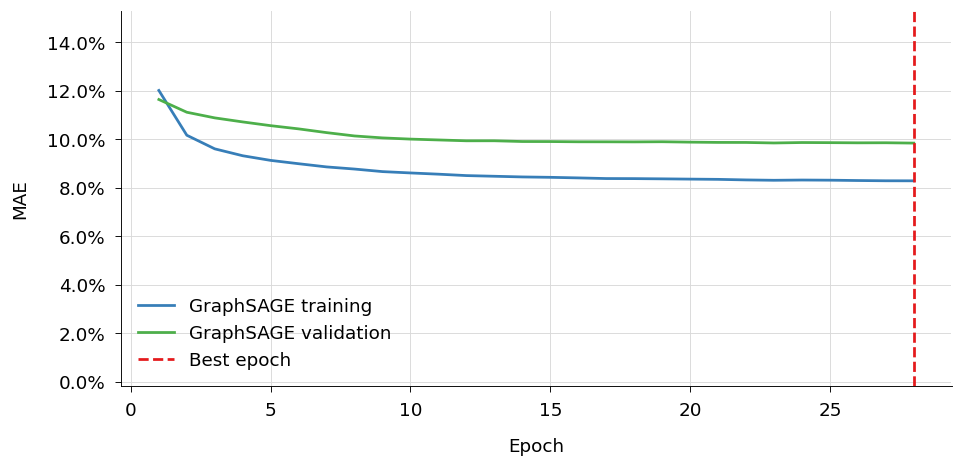

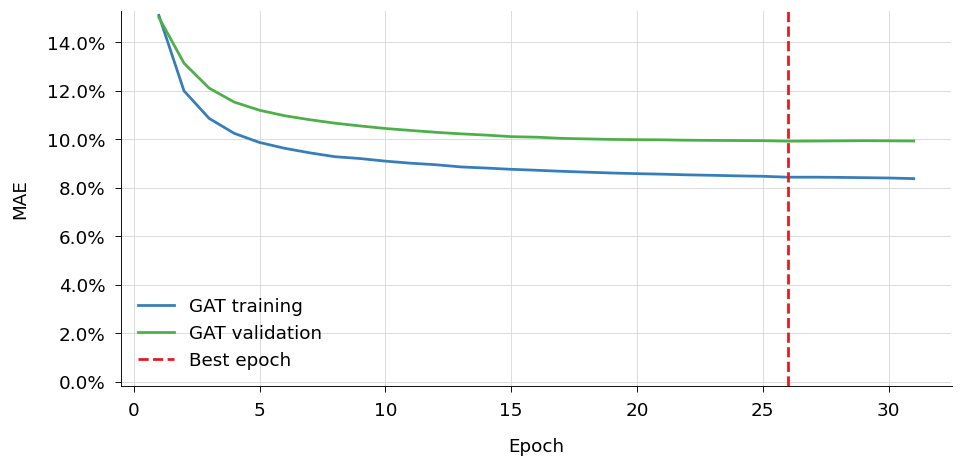

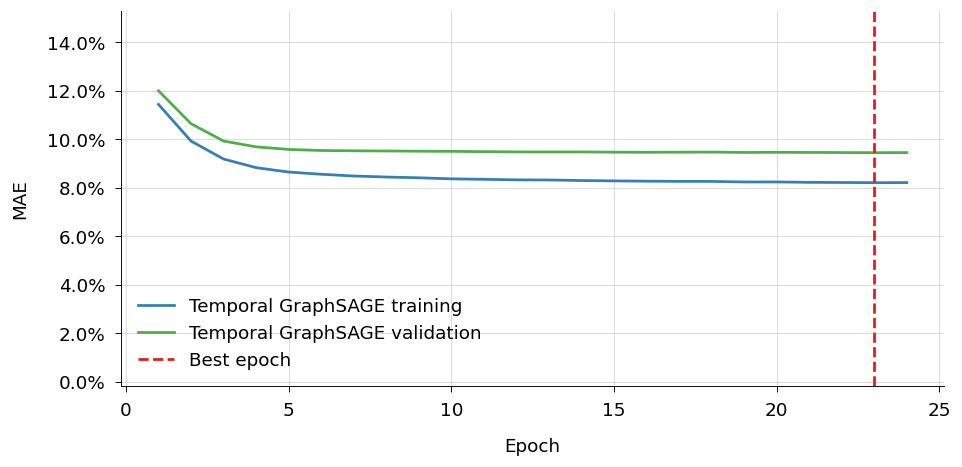

In [4]:
upper_limit = history[['training_l1', 'validation_mae']].max().max() + 0.002
best_epochs = performance.set_index('model')['best_epoch'].to_dict()

for model in ('graphsage', 'gat', 'temporal_graphsage'):
    rows = history.loc[history['model'].eq(model)]
    figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
    axis.plot(
        rows['epoch'], rows['training_l1'],
        color=COLOR_PALETTE[0], label=f'{model_labels[model]} training',
    )
    axis.plot(
        rows['epoch'], rows['validation_mae'],
        color=COLOR_PALETTE[2], label=f'{model_labels[model]} validation',
    )
    axis.axvline(
        best_epochs[model], color=COLOR_PALETTE[1],
        linestyle='--', label='Best epoch',
    )
    axis.set_xlabel('Epoch')
    axis.set_ylabel('MAE')
    axis.set_ylim(bottom=-0.002, top=upper_limit)
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    axis.legend()
    apply_matplotlib_layout(figure)
    figure.savefig(
        paths.figures / f'04_04_{model}_learning_curve.pdf'
    )
    plt.show()

## Temporal GraphSAGE tuning checks

The learning rate is first increased from 0.001 to 0.01 while retaining the original hidden dimension of 16. The previously estimated 32-dimensional specification is retained as a separate complexity check.

In [5]:
temporal_32_performance_path = (
    modeling_tables / 'temporal_graphsage_hidden_32_validation_performance.csv'
)
temporal_32_history_path = (
    modeling_tables / 'temporal_graphsage_hidden_32_training_history.csv'
)

if temporal_32_performance_path.is_file() and temporal_32_history_path.is_file():
    temporal_32_performance = pd.read_csv(temporal_32_performance_path).iloc[0].to_dict()
    temporal_32_history = pd.read_csv(temporal_32_history_path)
else:
    dataset = _load_graph_dataset(
        paths.processed / 'modeling' / 'gnn',
        {'train'},
        'validation',
    )
    temporal_32_performance, _, temporal_32_history = _fit_with_validation(
        'temporal_graphsage',
        dataset,
        project.seed,
        hidden_size=32,
        dropout=0.20,
        learning_rate=0.001,
        weight_decay=0.0001,
    )
    pd.DataFrame([temporal_32_performance]).to_csv(
        temporal_32_performance_path, index=False
    )
    temporal_32_history.to_csv(temporal_32_history_path, index=False)

temporal_16_lr_0010_performance_path = (
    modeling_tables / 'temporal_graphsage_hidden_16_lr_0010_validation_performance.csv'
)
temporal_16_lr_0010_history_path = (
    modeling_tables / 'temporal_graphsage_hidden_16_lr_0010_training_history.csv'
)

if (
    temporal_16_lr_0010_performance_path.is_file()
    and temporal_16_lr_0010_history_path.is_file()
):
    temporal_16_lr_0010_performance = pd.read_csv(
        temporal_16_lr_0010_performance_path
    ).iloc[0].to_dict()
    temporal_16_lr_0010_history = pd.read_csv(temporal_16_lr_0010_history_path)
else:
    if 'dataset' not in globals():
        dataset = _load_graph_dataset(
            paths.processed / 'modeling' / 'gnn',
            {'train'},
            'validation',
        )
    (
        temporal_16_lr_0010_performance,
        _,
        temporal_16_lr_0010_history,
    ) = _fit_with_validation(
        'temporal_graphsage',
        dataset,
        project.seed,
        hidden_size=16,
        dropout=0.20,
        learning_rate=0.01,
        weight_decay=0.0001,
    )
    pd.DataFrame([temporal_16_lr_0010_performance]).to_csv(
        temporal_16_lr_0010_performance_path, index=False
    )
    temporal_16_lr_0010_history.to_csv(
        temporal_16_lr_0010_history_path, index=False
    )

temporal_32_dropout_030_performance_path = (
    modeling_tables / 'temporal_graphsage_hidden_32_dropout_030_validation_performance.csv'
)
temporal_32_dropout_030_history_path = (
    modeling_tables / 'temporal_graphsage_hidden_32_dropout_030_training_history.csv'
)

if (
    temporal_32_dropout_030_performance_path.is_file()
    and temporal_32_dropout_030_history_path.is_file()
):
    temporal_32_dropout_030_performance = pd.read_csv(
        temporal_32_dropout_030_performance_path
    ).iloc[0].to_dict()
    temporal_32_dropout_030_history = pd.read_csv(
        temporal_32_dropout_030_history_path
    )
else:
    if 'dataset' not in globals():
        dataset = _load_graph_dataset(
            paths.processed / 'modeling' / 'gnn',
            {'train'},
            'validation',
        )
    (
        temporal_32_dropout_030_performance,
        _,
        temporal_32_dropout_030_history,
    ) = _fit_with_validation(
        'temporal_graphsage',
        dataset,
        project.seed,
        hidden_size=32,
        dropout=0.30,
        learning_rate=0.001,
        weight_decay=0.0001,
    )
    pd.DataFrame([temporal_32_dropout_030_performance]).to_csv(
        temporal_32_dropout_030_performance_path, index=False
    )
    temporal_32_dropout_030_history.to_csv(
        temporal_32_dropout_030_history_path, index=False
    )

temporal_64_dropout_030_performance_path = (
    modeling_tables / 'temporal_graphsage_hidden_64_dropout_030_validation_performance.csv'
)
temporal_64_dropout_030_history_path = (
    modeling_tables / 'temporal_graphsage_hidden_64_dropout_030_training_history.csv'
)

if (
    temporal_64_dropout_030_performance_path.is_file()
    and temporal_64_dropout_030_history_path.is_file()
):
    temporal_64_dropout_030_performance = pd.read_csv(
        temporal_64_dropout_030_performance_path
    ).iloc[0].to_dict()
    temporal_64_dropout_030_history = pd.read_csv(
        temporal_64_dropout_030_history_path
    )
else:
    if 'dataset' not in globals():
        dataset = _load_graph_dataset(
            paths.processed / 'modeling' / 'gnn',
            {'train'},
            'validation',
        )
    (
        temporal_64_dropout_030_performance,
        _,
        temporal_64_dropout_030_history,
    ) = _fit_with_validation(
        'temporal_graphsage',
        dataset,
        project.seed,
        hidden_size=64,
        dropout=0.30,
        learning_rate=0.001,
        weight_decay=0.0001,
    )
    pd.DataFrame([temporal_64_dropout_030_performance]).to_csv(
        temporal_64_dropout_030_performance_path, index=False
    )
    temporal_64_dropout_030_history.to_csv(
        temporal_64_dropout_030_history_path, index=False
    )

In [6]:
baseline_temporal = performance.loc[
    performance['model'].eq('temporal_graphsage')
].iloc[0]
baseline_checkpoint = history.loc[
    history['model'].eq('temporal_graphsage')
    & history['epoch'].eq(baseline_temporal['best_epoch'])
].iloc[0]
temporal_32_checkpoint = temporal_32_history.loc[
    temporal_32_history['epoch'].eq(temporal_32_performance['best_epoch'])
].iloc[0]
temporal_16_lr_0010_checkpoint = temporal_16_lr_0010_history.loc[
    temporal_16_lr_0010_history['epoch'].eq(
        temporal_16_lr_0010_performance['best_epoch']
    )
].iloc[0]
temporal_32_dropout_030_checkpoint = temporal_32_dropout_030_history.loc[
    temporal_32_dropout_030_history['epoch'].eq(
        temporal_32_dropout_030_performance['best_epoch']
    )
].iloc[0]
temporal_64_dropout_030_checkpoint = temporal_64_dropout_030_history.loc[
    temporal_64_dropout_030_history['epoch'].eq(
        temporal_64_dropout_030_performance['best_epoch']
    )
].iloc[0]

temporal_comparison = pd.DataFrame([
    {
        'hidden_dimension': 16,
        'learning_rate': 0.001,
        'dropout': 0.20,
        'best_epoch': int(baseline_temporal['best_epoch']),
        'training_mae': baseline_checkpoint['training_l1'],
        'validation_mae': baseline_temporal['mae'],
        'validation_rmse': baseline_temporal['rmse'],
        'validation_r2': baseline_temporal['r2'],
        'mean_quarterly_spearman': baseline_temporal['mean_quarterly_spearman'],
    },
    {
        'hidden_dimension': 32,
        'learning_rate': 0.001,
        'dropout': 0.20,
        'best_epoch': int(temporal_32_performance['best_epoch']),
        'training_mae': temporal_32_checkpoint['training_l1'],
        'validation_mae': temporal_32_performance['mae'],
        'validation_rmse': temporal_32_performance['rmse'],
        'validation_r2': temporal_32_performance['r2'],
        'mean_quarterly_spearman': temporal_32_performance['mean_quarterly_spearman'],
    },
    {
        'hidden_dimension': 16,
        'learning_rate': 0.01,
        'dropout': 0.20,
        'best_epoch': int(temporal_16_lr_0010_performance['best_epoch']),
        'training_mae': temporal_16_lr_0010_checkpoint['training_l1'],
        'validation_mae': temporal_16_lr_0010_performance['mae'],
        'validation_rmse': temporal_16_lr_0010_performance['rmse'],
        'validation_r2': temporal_16_lr_0010_performance['r2'],
        'mean_quarterly_spearman': (
            temporal_16_lr_0010_performance['mean_quarterly_spearman']
        ),
    },
    {
        'hidden_dimension': 64,
        'learning_rate': 0.001,
        'dropout': 0.30,
        'best_epoch': int(temporal_64_dropout_030_performance['best_epoch']),
        'training_mae': temporal_64_dropout_030_checkpoint['training_l1'],
        'validation_mae': temporal_64_dropout_030_performance['mae'],
        'validation_rmse': temporal_64_dropout_030_performance['rmse'],
        'validation_r2': temporal_64_dropout_030_performance['r2'],
        'mean_quarterly_spearman': (
            temporal_64_dropout_030_performance['mean_quarterly_spearman']
        ),
    },
    {
        'hidden_dimension': 32,
        'learning_rate': 0.001,
        'dropout': 0.30,
        'best_epoch': int(temporal_32_dropout_030_performance['best_epoch']),
        'training_mae': temporal_32_dropout_030_checkpoint['training_l1'],
        'validation_mae': temporal_32_dropout_030_performance['mae'],
        'validation_rmse': temporal_32_dropout_030_performance['rmse'],
        'validation_r2': temporal_32_dropout_030_performance['r2'],
        'mean_quarterly_spearman': (
            temporal_32_dropout_030_performance['mean_quarterly_spearman']
        ),
    },
])
temporal_comparison = temporal_comparison.sort_values(
    ['hidden_dimension', 'learning_rate', 'dropout']
).reset_index(drop=True)
temporal_comparison['generalization_gap'] = (
    temporal_comparison['validation_mae'] - temporal_comparison['training_mae']
)
temporal_comparison['selected'] = temporal_comparison['validation_mae'].eq(
    temporal_comparison['validation_mae'].min()
)
temporal_comparison.to_csv(
    modeling_tables / 'temporal_graphsage_configuration_comparison.csv',
    index=False,
)
temporal_comparison.rename(columns={
    'hidden_dimension': 'Hidden dimension',
    'learning_rate': 'Learning rate',
    'dropout': 'Dropout',
    'best_epoch': 'Best epoch',
    'training_mae': 'Training MAE',
    'validation_mae': 'Validation MAE',
    'validation_rmse': 'Validation RMSE',
    'validation_r2': 'Validation R2',
    'mean_quarterly_spearman': 'Mean quarterly Spearman',
    'generalization_gap': 'Gap',
    'selected': 'Selected',
}).to_latex(
    paths.tables / '04_04_temporal_graphsage_configuration_comparison.tex',
    index=False,
    escape=True,
    float_format='%.4f',
    caption='Validation performance of the Temporal GraphSAGE configurations.',
    label='tab:temporal-graphsage-configuration-comparison',
)
display(temporal_comparison.style.format({
    'learning_rate': '{:.3f}',
    'dropout': '{:.2f}',
    'training_mae': '{:.4f}',
    'validation_mae': '{:.4f}',
    'validation_rmse': '{:.4f}',
    'validation_r2': '{:.3f}',
    'mean_quarterly_spearman': '{:.3f}',
    'generalization_gap': '{:.4f}',
}))

,hidden_dimension,learning_rate,dropout,best_epoch,training_mae,validation_mae,validation_rmse,validation_r2,mean_quarterly_spearman,generalization_gap,selected
0,16,0.001,0.20,23,0.0821,0.0945,0.1345,0.442,0.746,0.0124,False
1,16,0.010,0.20,26,0.0837,0.0976,0.1372,0.420,0.735,0.0139,False
2,32,0.001,0.20,28,0.0813,0.0941,0.1348,0.440,0.748,0.0128,True
3,32,0.001,0.30,20,0.0821,0.0943,0.1347,0.441,0.746,0.0122,False
4,64,0.001,0.30,4,0.0888,0.0962,0.1360,0.430,0.733,0.0074,False


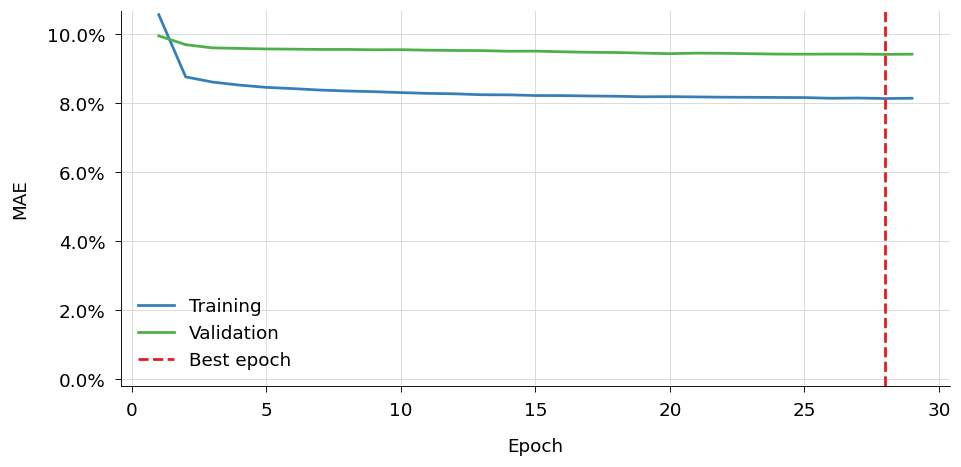

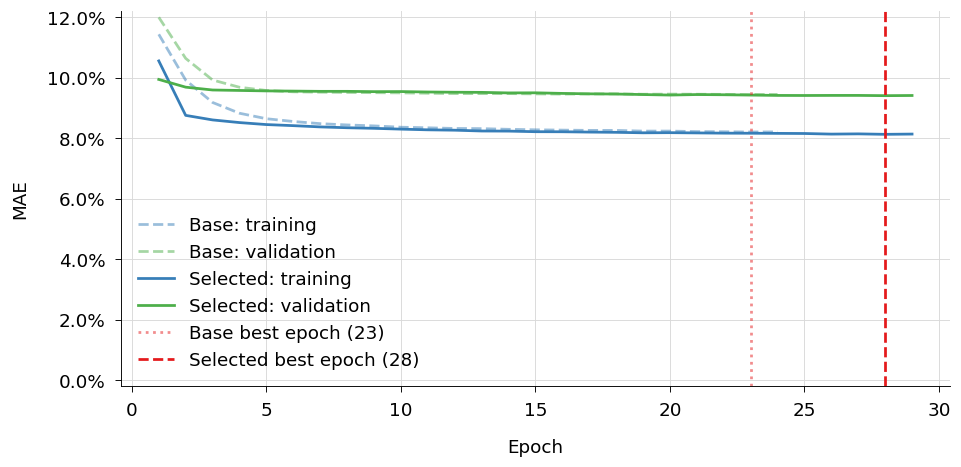

In [ ]:
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    temporal_32_history['epoch'], temporal_32_history['training_l1'],
    color=COLOR_PALETTE[0], label='Training',
)
axis.plot(
    temporal_32_history['epoch'], temporal_32_history['validation_mae'],
    color=COLOR_PALETTE[2], label='Validation',
)
axis.axvline(
    temporal_32_performance['best_epoch'],
    color=COLOR_PALETTE[1], linestyle='--', label='Best epoch',
)
axis.set_xlabel('Epoch')
axis.set_ylabel('MAE')
axis.set_ylim(bottom=-0.002)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_04_temporal_graphsage_hidden_32_learning_curve.pdf'
)
plt.show()

base_history = history.loc[history['model'].eq('temporal_graphsage')]
selected_history = temporal_32_history
base_best_epoch = int(baseline_temporal['best_epoch'])
selected_best_epoch = int(temporal_32_performance['best_epoch'])
comparison_upper_limit = (
    pd.concat([
        base_history[['training_l1', 'validation_mae']],
        selected_history[['training_l1', 'validation_mae']],
    ]).max().max() + 0.002
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    base_history['epoch'], base_history['training_l1'],
    color=COLOR_PALETTE[0], linestyle='--', alpha=0.5,
    label='Base: training',
)
axis.plot(
    base_history['epoch'], base_history['validation_mae'],
    color=COLOR_PALETTE[2], linestyle='--', alpha=0.5,
    label='Base: validation',
)
axis.plot(
    selected_history['epoch'], selected_history['training_l1'],
    color=COLOR_PALETTE[0], label='Selected: training',
)
axis.plot(
    selected_history['epoch'], selected_history['validation_mae'],
    color=COLOR_PALETTE[2], label='Selected: validation',
)
axis.axvline(
    base_best_epoch, color=COLOR_PALETTE[1], linestyle=':', alpha=0.5,
    label=f'Base best epoch ({base_best_epoch})',
)
axis.axvline(
    selected_best_epoch, color=COLOR_PALETTE[1], linestyle='--',
    label=f'Selected best epoch ({selected_best_epoch})',
)
axis.set_xlabel('Epoch')
axis.set_ylabel('MAE')
axis.set_ylim(bottom=-0.002, top=comparison_upper_limit)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures
    / '04_04_temporal_graphsage_base_vs_selected_learning_curve.pdf'
)
plt.show()

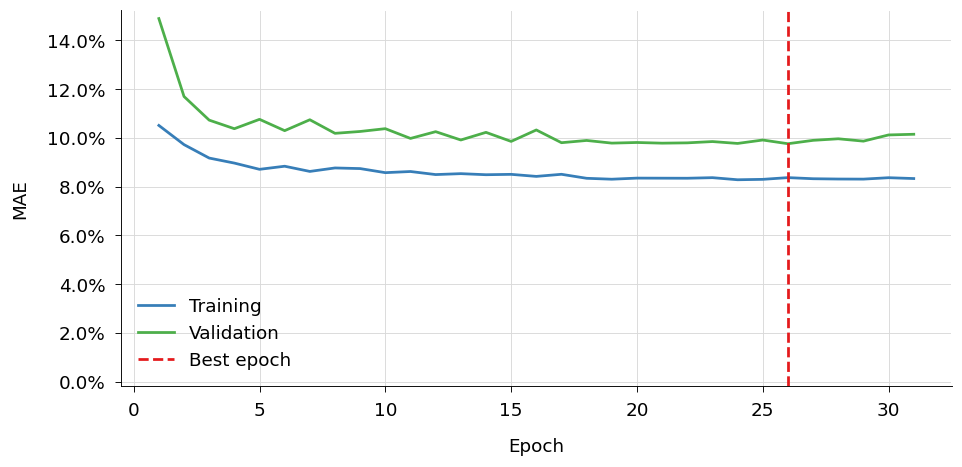

In [8]:
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    temporal_16_lr_0010_history['epoch'],
    temporal_16_lr_0010_history['training_l1'],
    color=COLOR_PALETTE[0], label='Training',
)
axis.plot(
    temporal_16_lr_0010_history['epoch'],
    temporal_16_lr_0010_history['validation_mae'],
    color=COLOR_PALETTE[2], label='Validation',
)
axis.axvline(
    temporal_16_lr_0010_performance['best_epoch'],
    color=COLOR_PALETTE[1], linestyle='--', label='Best epoch',
)
axis.set_xlabel('Epoch')
axis.set_ylabel('MAE')
axis.set_ylim(bottom=-0.002)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_04_temporal_graphsage_hidden_16_lr_0010_learning_curve.pdf'
)
plt.show()

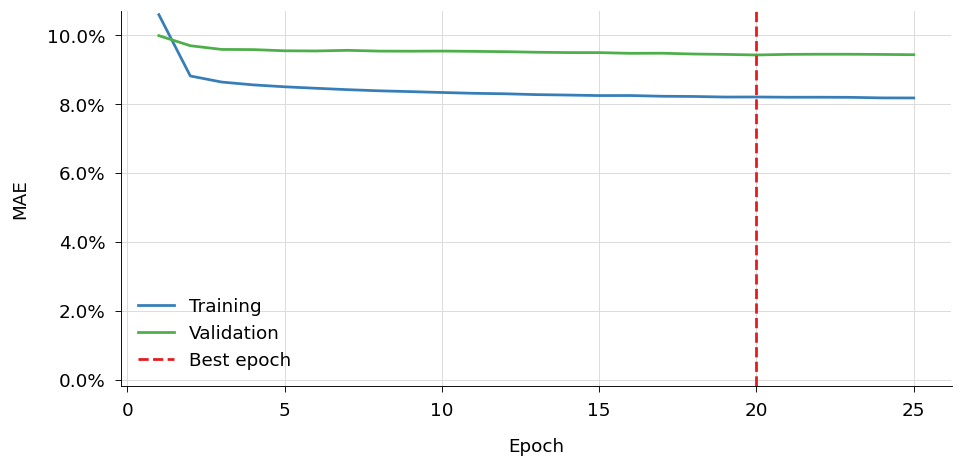

In [9]:
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    temporal_32_dropout_030_history['epoch'],
    temporal_32_dropout_030_history['training_l1'],
    color=COLOR_PALETTE[0], label='Training',
)
axis.plot(
    temporal_32_dropout_030_history['epoch'],
    temporal_32_dropout_030_history['validation_mae'],
    color=COLOR_PALETTE[2], label='Validation',
)
axis.axvline(
    temporal_32_dropout_030_performance['best_epoch'],
    color=COLOR_PALETTE[1], linestyle='--', label='Best epoch',
)
axis.set_xlabel('Epoch')
axis.set_ylabel('MAE')
axis.set_ylim(bottom=-0.002)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_04_temporal_graphsage_hidden_32_dropout_030_learning_curve.pdf'
)
plt.show()

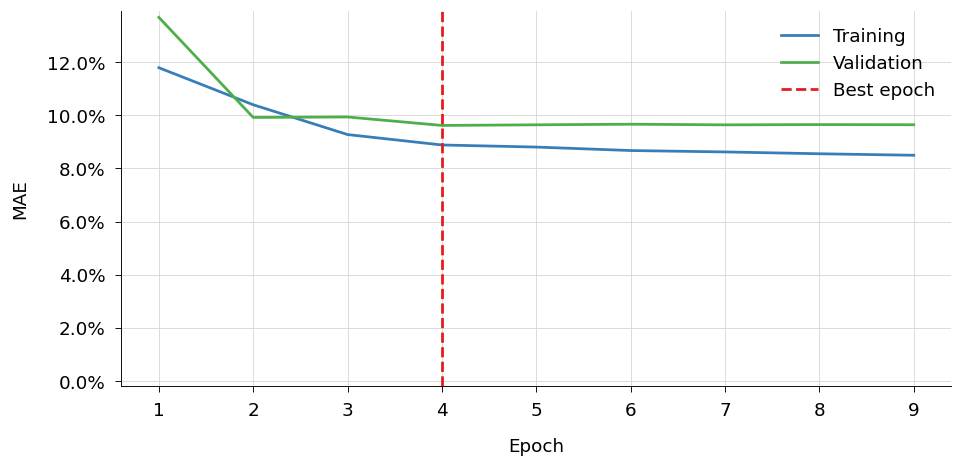

In [10]:
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    temporal_64_dropout_030_history['epoch'],
    temporal_64_dropout_030_history['training_l1'],
    color=COLOR_PALETTE[0], label='Training',
)
axis.plot(
    temporal_64_dropout_030_history['epoch'],
    temporal_64_dropout_030_history['validation_mae'],
    color=COLOR_PALETTE[2], label='Validation',
)
axis.axvline(
    temporal_64_dropout_030_performance['best_epoch'],
    color=COLOR_PALETTE[1], linestyle='--', label='Best epoch',
)
axis.set_xlabel('Epoch')
axis.set_ylabel('MAE')
axis.set_ylim(bottom=-0.002)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_04_temporal_graphsage_hidden_64_dropout_030_learning_curve.pdf'
)
plt.show()